In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

cpu


In [2]:
puck_list = ['Puck_230517_39'] # the largest puck
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1",
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr",
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
head = 0
adata, X,Y, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)

['Lhb', 'Cga'] dropped from gene_list due to not being observed.


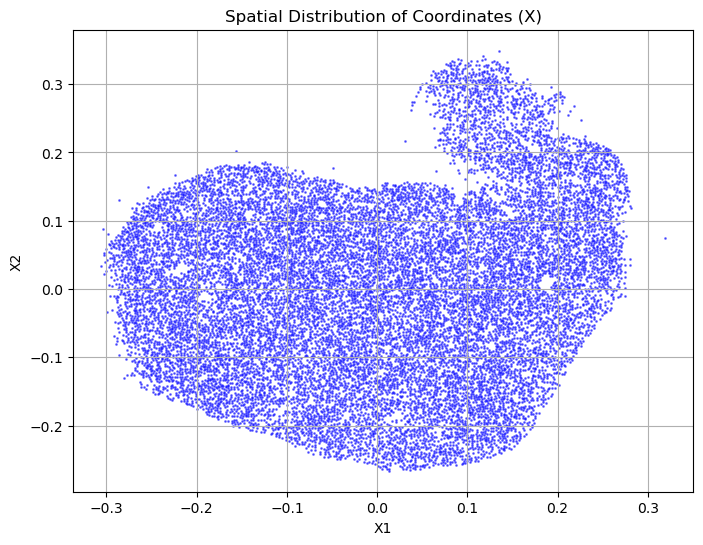

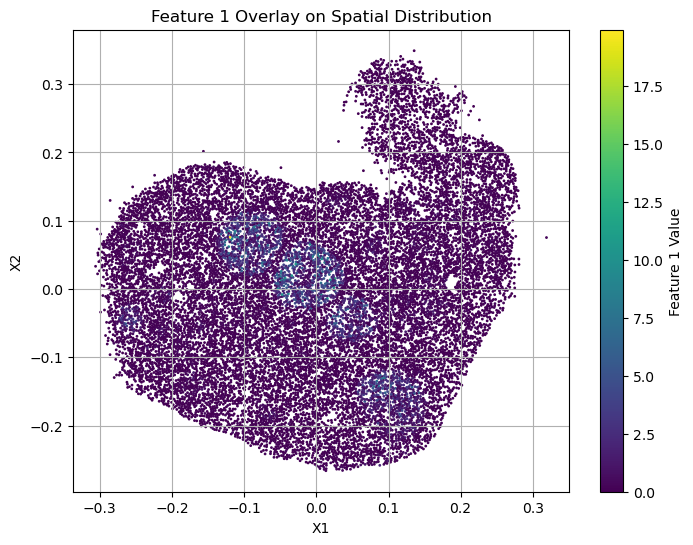

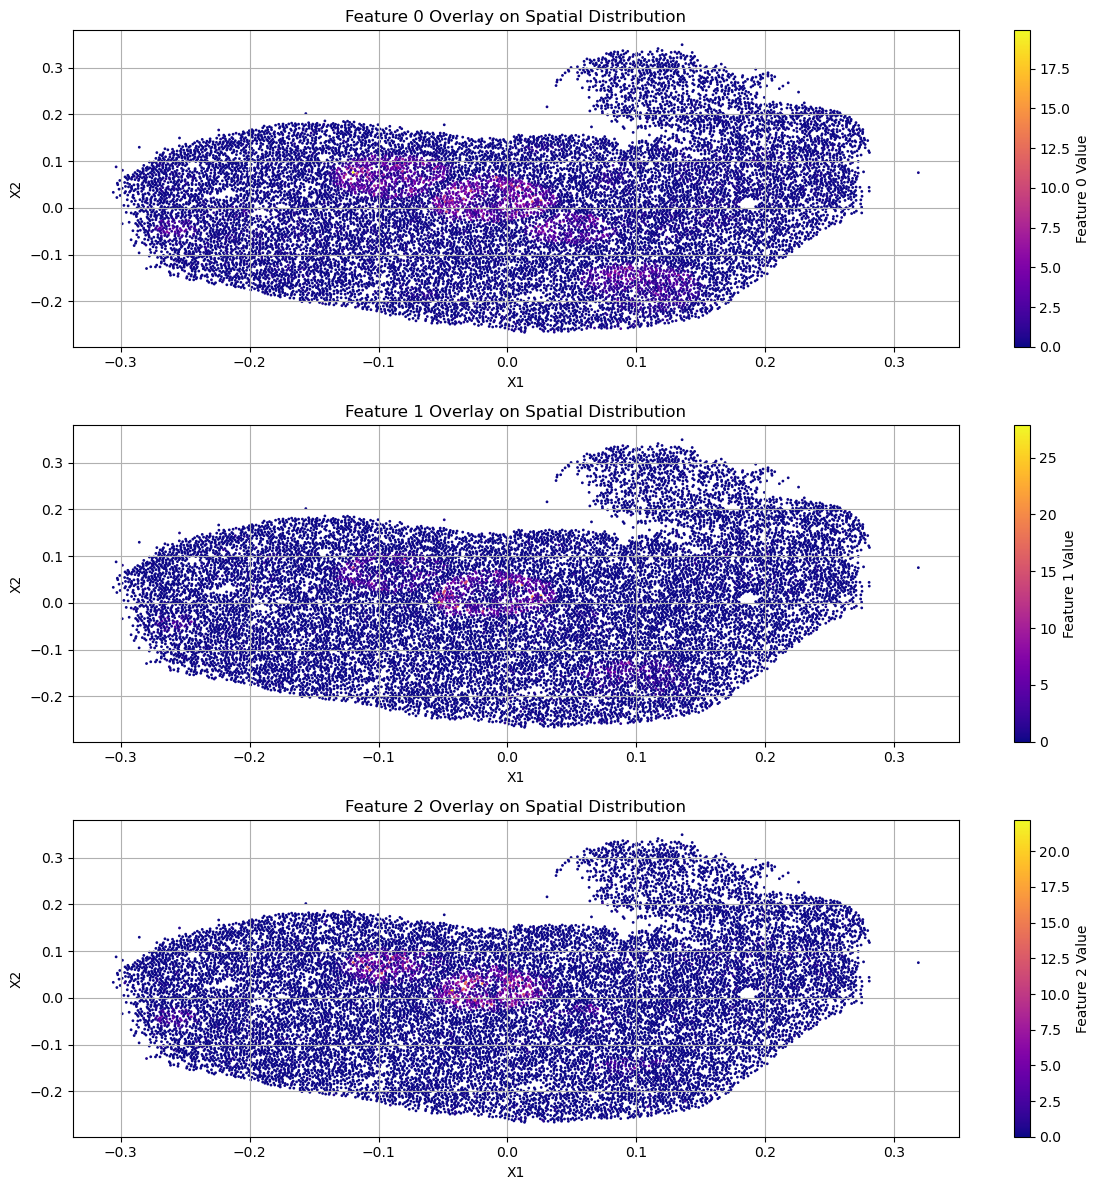

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Function to plot spatial scatter plot of coordinates
def plot_coordinates(X):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], s=1, color='blue', alpha=0.5)
    plt.title("Spatial Distribution of Coordinates (X)")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid()
    plt.show()

# Function to overlay a feature on the spatial distribution
def plot_feature_overlay(X, Y, feature_index=0):
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(X[:, 0], X[:, 1], c=Y[:, feature_index], cmap="viridis", s=1)
    plt.title(f"Feature {feature_index + 1} Overlay on Spatial Distribution")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.colorbar(sc, label=f"Feature {feature_index + 1} Value")
    plt.grid()
    plt.show()

# Function to plot multiple feature distributions
def plot_multiple_features(X, Y, feature_indices=[0, 1, 2]):
    num_features = len(feature_indices)
    plt.figure(figsize=(12, 4 * num_features))
    for i, feature_index in enumerate(feature_indices):
        plt.subplot(num_features, 1, i + 1)
        sc = plt.scatter(X[:, 0], X[:, 1], c=Y[:, feature_index], cmap="plasma", s=1)
        plt.title(f"Feature {feature_index} Overlay on Spatial Distribution")
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.colorbar(sc, label=f"Feature {feature_index} Value")
        plt.grid()
    plt.tight_layout()
    plt.show()

# Visualizations
plot_coordinates(X)                 # Spatial scatter plot
plot_feature_overlay(X, Y, 0)       # Overlay first feature
plot_multiple_features(X, Y, [0, 1, 2])  # Overlay multiple features

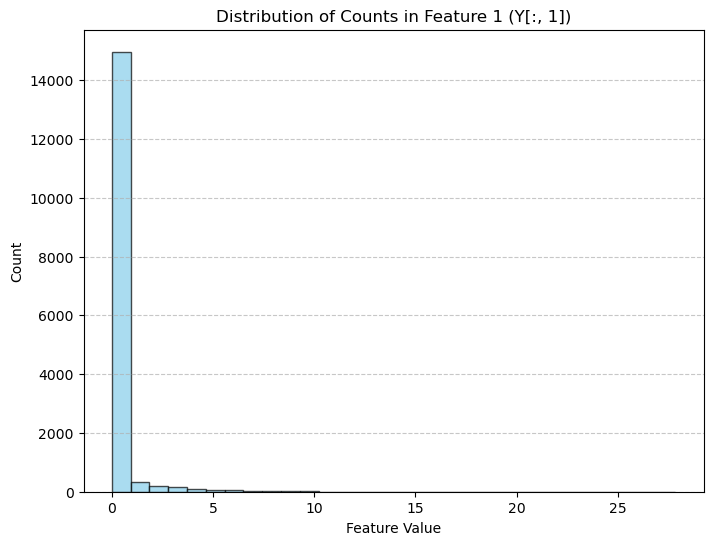

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for visualization
# Extract the second feature (Y[:, 1])
feature_values = Y[:, 1]

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(feature_values, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
plt.title("Distribution of Counts in Feature 1 (Y[:, 1])")
plt.xlabel("Feature Value")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [5]:
feature_values.unique()

tensor([ 0.0000,  0.6987,  1.3973,  2.0957,  2.7940,  3.4922,  4.1903,  4.8882,
         5.5860,  6.2837,  6.9812,  7.6786,  8.3759,  9.0730,  9.7700, 10.4669,
        11.1636, 11.8602, 12.5567, 13.2531, 13.9493, 14.6454, 16.0372, 19.5144,
        20.9043, 21.5991, 27.8464], dtype=torch.float64)

In [6]:
# Identify rows in Y where all values are zero
all_zero_rows = torch.all(Y == 0, dim=1)  # Boolean mask

# Count the number of such locations
zero_count = torch.sum(all_zero_rows).item()

# Print the result
print(f"Number of locations in X with all-zero gene expressions in Y: {zero_count}")

Number of locations in X with all-zero gene expressions in Y: 1869


In [7]:
overall_number_of_cells = 0

for j in range(22):
    j_nonzero_rows = torch.sum(Y != 0, dim=1) == j  # Boolean mask for rows with exactly j nonzero value

    # Count the number of such locations
    j_nonzero_count = torch.sum(j_nonzero_rows).item()

    # Print the result
    print(f"Number of locations in X with exactly {j} nonzero gene expression(s) in Y: {j_nonzero_count}")
    overall_number_of_cells += j_nonzero_count

overall_number_of_cells

Number of locations in X with exactly 0 nonzero gene expression(s) in Y: 1869
Number of locations in X with exactly 1 nonzero gene expression(s) in Y: 3836
Number of locations in X with exactly 2 nonzero gene expression(s) in Y: 3840
Number of locations in X with exactly 3 nonzero gene expression(s) in Y: 2719
Number of locations in X with exactly 4 nonzero gene expression(s) in Y: 1660
Number of locations in X with exactly 5 nonzero gene expression(s) in Y: 1064
Number of locations in X with exactly 6 nonzero gene expression(s) in Y: 520
Number of locations in X with exactly 7 nonzero gene expression(s) in Y: 269
Number of locations in X with exactly 8 nonzero gene expression(s) in Y: 96
Number of locations in X with exactly 9 nonzero gene expression(s) in Y: 24
Number of locations in X with exactly 10 nonzero gene expression(s) in Y: 9
Number of locations in X with exactly 11 nonzero gene expression(s) in Y: 1
Number of locations in X with exactly 12 nonzero gene expression(s) in Y: 

15907

In [8]:
X.shape

torch.Size([15907, 2])

In [9]:
Y.shape

torch.Size([15907, 22])

In [10]:
for j in range(22):
    print("gene", j, "sum of expressions", sum(Y[:, j]).item())

gene 0 sum of expressions 5964.6612710925465
gene 1 sum of expressions 3713.128666385867
gene 2 sum of expressions 3633.8202826062534
gene 3 sum of expressions 4416.623055721667
gene 4 sum of expressions 3324.227454538423
gene 5 sum of expressions 3788.457360890287
gene 6 sum of expressions 645.9293038718572
gene 7 sum of expressions 5066.821499860294
gene 8 sum of expressions 1618.80606941607
gene 9 sum of expressions 539.0886197137543
gene 10 sum of expressions 11431.809429344967
gene 11 sum of expressions 4088.3363544192753
gene 12 sum of expressions 2370.6152570682016
gene 13 sum of expressions 2380.965773392373
gene 14 sum of expressions 1983.1440358798377
gene 15 sum of expressions 8313.110242002227
gene 16 sum of expressions 3082.0673301529364
gene 17 sum of expressions 4201.267803283503
gene 18 sum of expressions 2888.097725786301
gene 19 sum of expressions 1719.0918986712873
gene 20 sum of expressions 983.3969557098529
gene 21 sum of expressions 3004.3001990169773


number of cells that see gene 0 : 5395
number of cells that see gene 1 : 1956
number of cells that see gene 2 : 1711
number of cells that see gene 3 : 1674
number of cells that see gene 4 : 762
number of cells that see gene 5 : 1127
number of cells that see gene 6 : 27
number of cells that see gene 7 : 1755
number of cells that see gene 8 : 201
number of cells that see gene 9 : 19
number of cells that see gene 10 : 11042
number of cells that see gene 11 : 1283
number of cells that see gene 12 : 415
number of cells that see gene 13 : 759
number of cells that see gene 14 : 283
number of cells that see gene 15 : 5132
number of cells that see gene 16 : 843
number of cells that see gene 17 : 1774
number of cells that see gene 18 : 585
number of cells that see gene 19 : 201
number of cells that see gene 20 : 63
number of cells that see gene 21 : 714
genes which are found in more than 1/8 of the cells
0
10
15


(array([7., 5., 2., 5., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1.]),
 array([0.00119444, 0.03584271, 0.07049098, 0.10513925, 0.13978751,
        0.17443578, 0.20908405, 0.24373232, 0.27838059, 0.31302886,
        0.34767712, 0.38232539, 0.41697366, 0.45162193, 0.4862702 ,
        0.52091846, 0.55556673, 0.590215  , 0.62486327, 0.65951154,
        0.6941598 ]),
 <BarContainer object of 20 artists>)

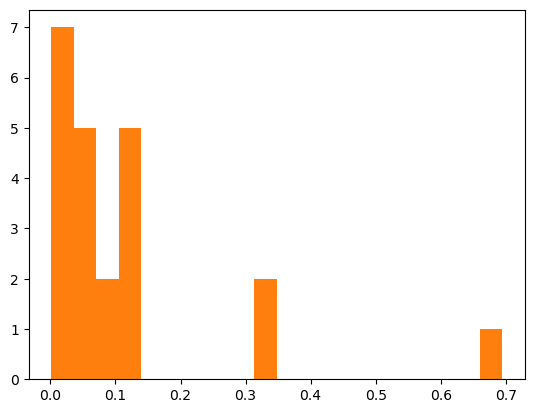

In [14]:
nonzero_counts = []
for j in range(22):
    nonzero_count = torch.sum(Y[:, j] != 0).item()
    print("number of cells that see gene", j, ":", nonzero_count)
    nonzero_counts.append(nonzero_count/15907)

print("\ngenes which are found in more than 1/8 of the cells")
for j in range(22):
    nonzero_count = torch.sum(Y[:, j] != 0).item()
    if nonzero_count > 15907/8:
        print(j)
plt.hist(nonzero_counts, bins=20)

plt.hist(nonzero_counts, bins=20)

# Think of it as a spatial point process

In [15]:
# Number of genes
num_genes = Y.shape[1]
num_genes

22

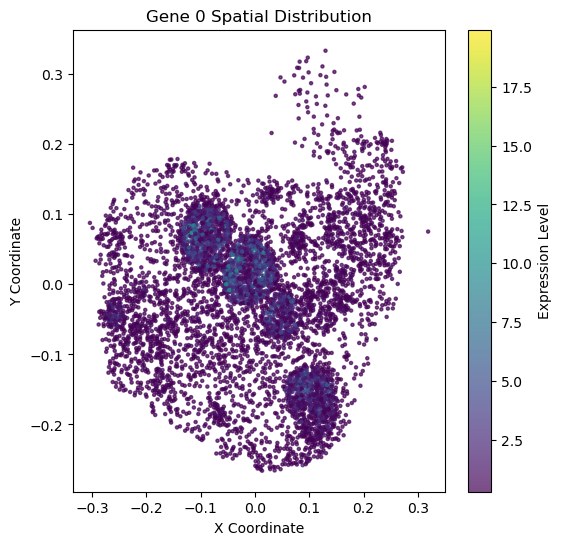

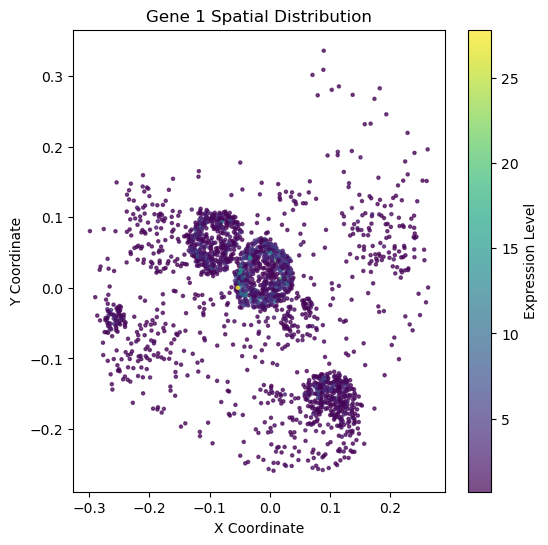

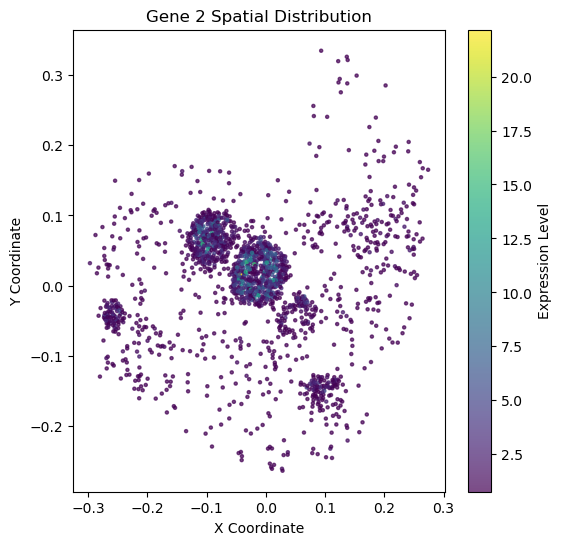

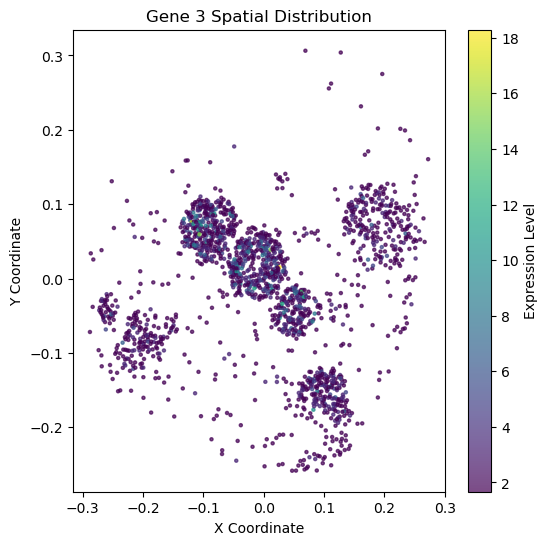

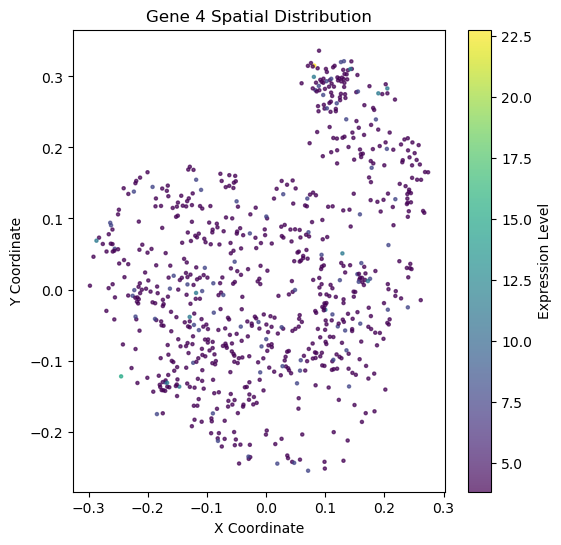

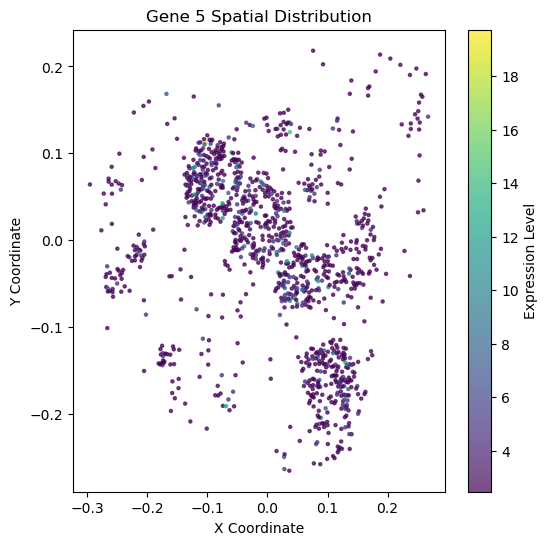

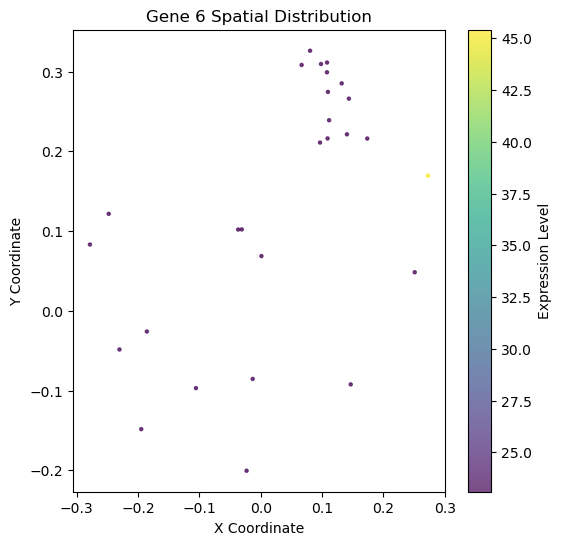

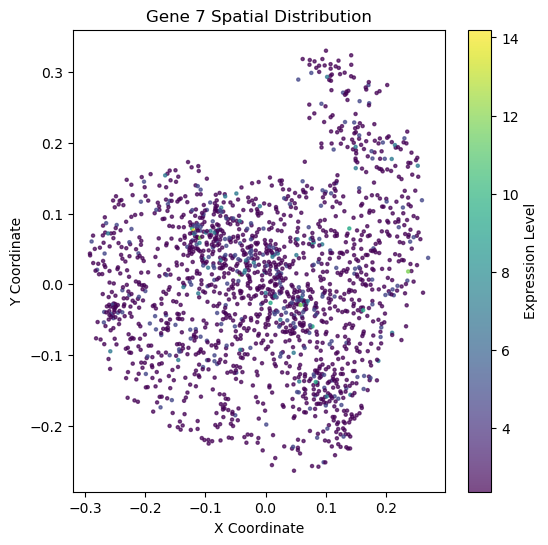

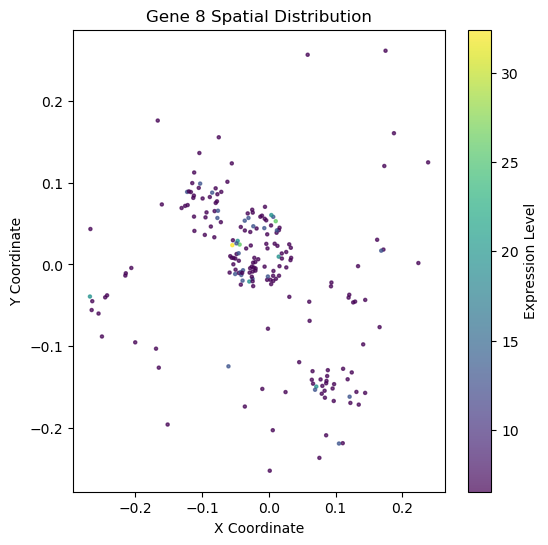

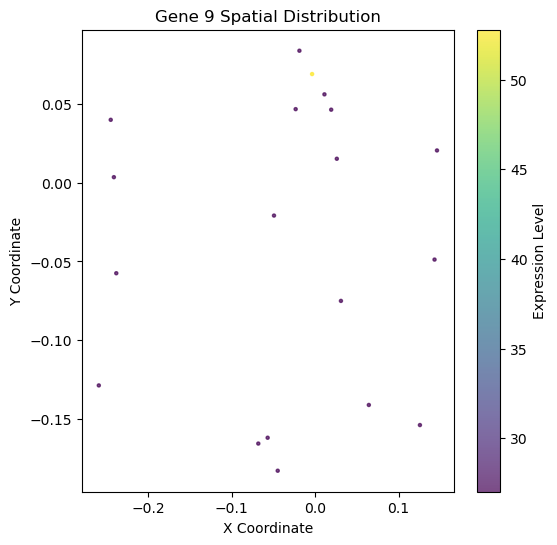

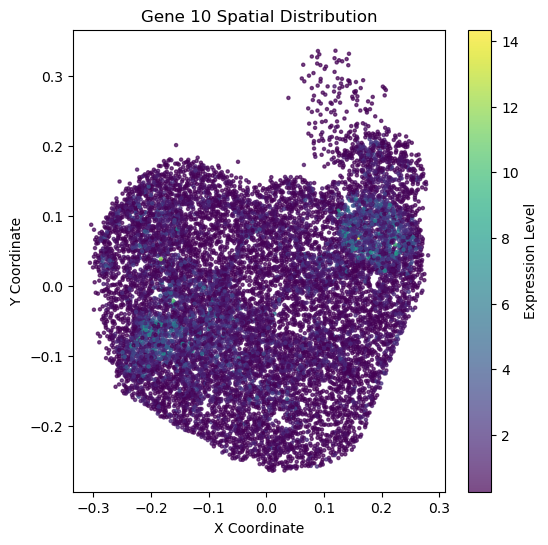

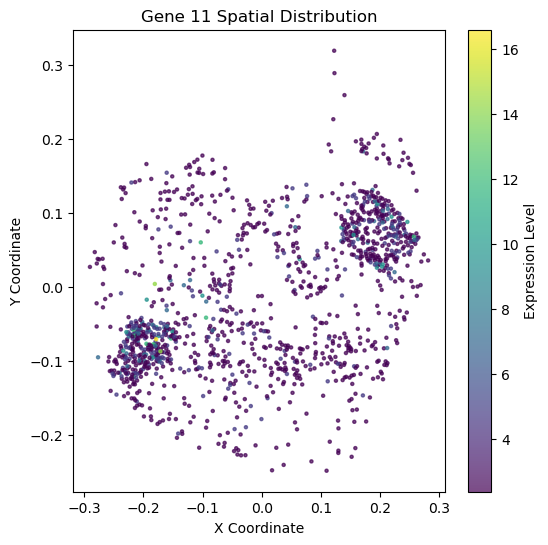

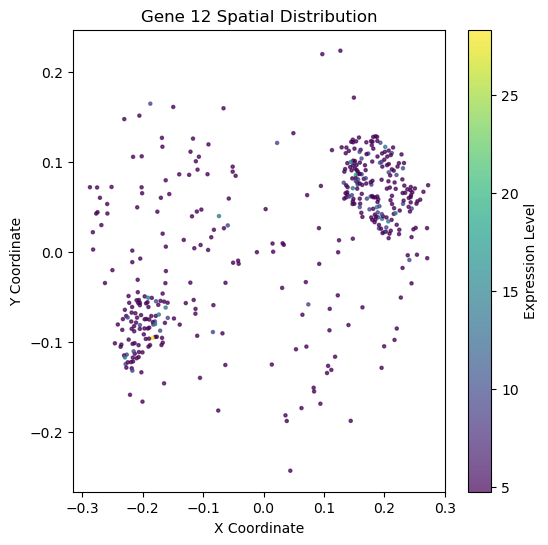

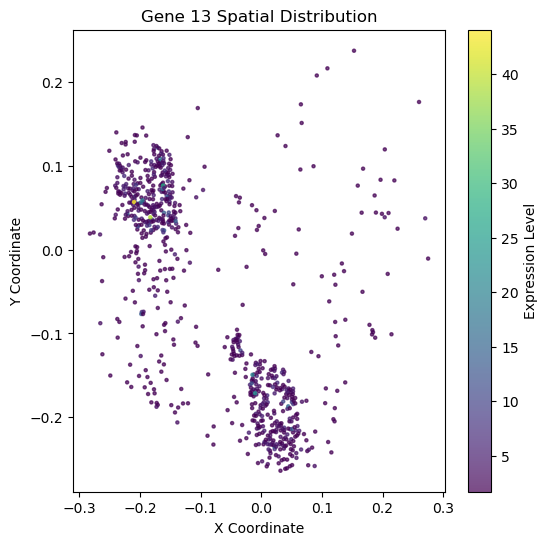

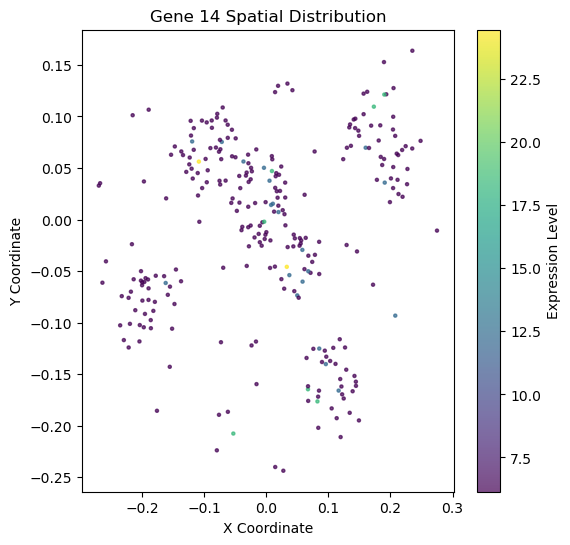

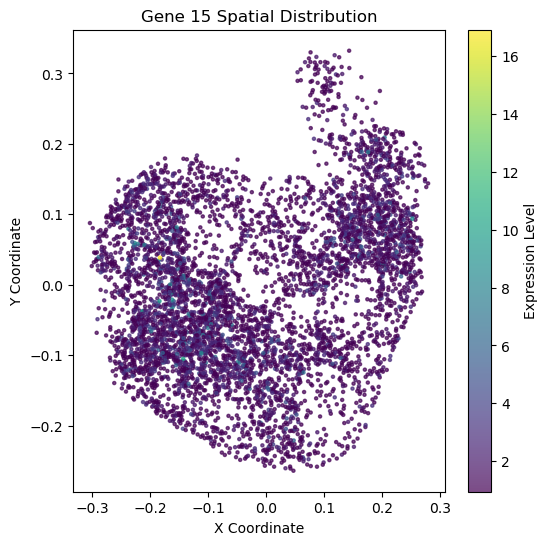

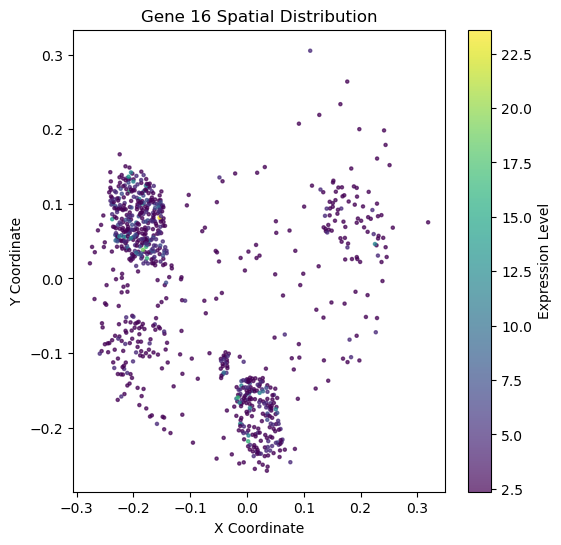

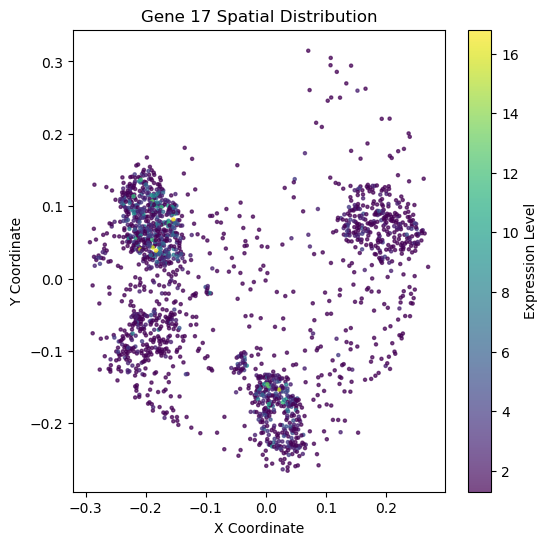

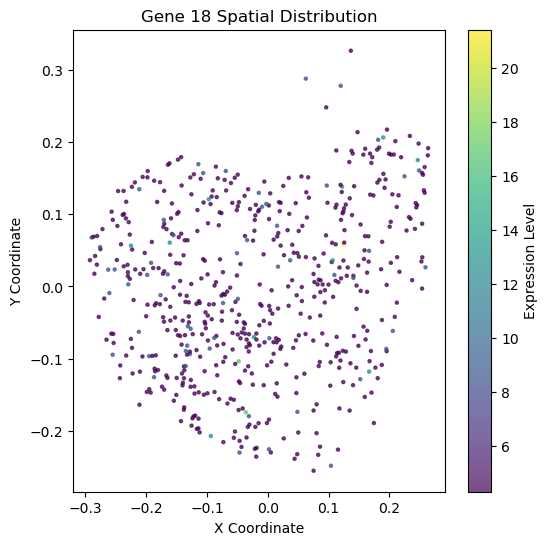

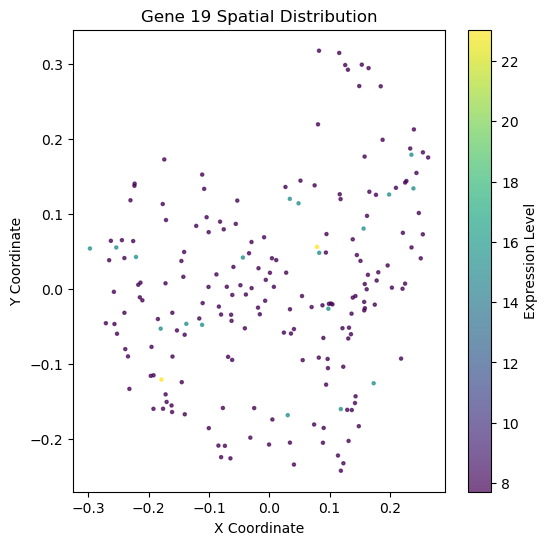

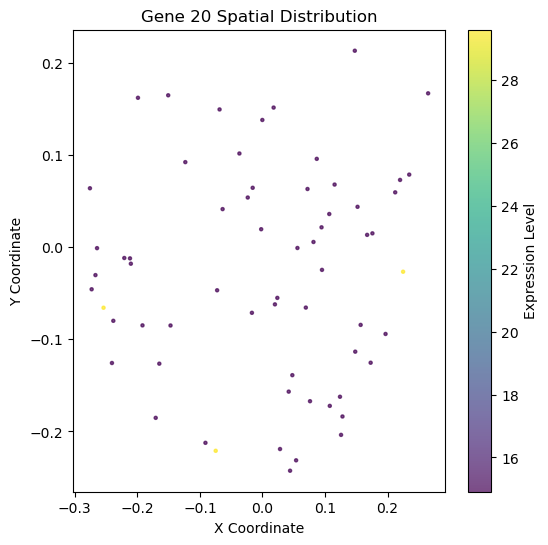

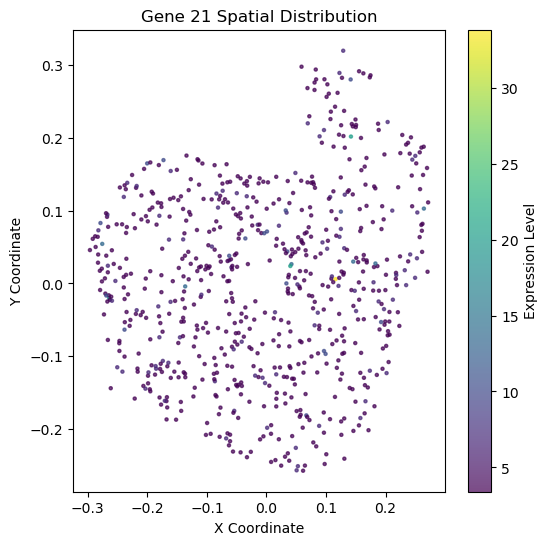

In [18]:
# Generate scatterplots for the first two genes (for testing)
for gene_idx in range(22):  # Adjust range for fewer plots
    valid_indices = (Y[:, gene_idx] > 0).nonzero(as_tuple=True)[0]
    X_filtered = X[valid_indices]
    Y_filtered = Y[valid_indices, gene_idx]

    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=Y_filtered, cmap='viridis', s=5, alpha=0.7)
    plt.colorbar(label='Expression Level')
    plt.title(f"Gene {gene_idx} Spatial Distribution")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.show()

In [28]:
[gene_list[i] for i in [6,9]]

['Pgr', 'Cyp17a1']

In [25]:
[gene_list[i] for i in [0, 10, 15]]

['Inha', 'Cyp11a1', 'Star']

### 1. **`Inha` (Inhibin Subunit Alpha)**

- **Function**: 
  - The **`Inha`** gene encodes the **alpha subunit** of the protein **inhibin**, a hormone involved in regulating reproductive physiology.
  - Inhibin is a heterodimeric protein composed of an alpha subunit (encoded by `Inha`) and one of two beta subunits (encoded by other genes, like `Inhbb`).
  - It is primarily produced in the gonads (ovaries and testes) and acts to inhibit the secretion of follicle-stimulating hormone (**FSH**) from the anterior pituitary gland.

- **Biological Importance**:
  - Plays a critical role in **feedback regulation** of the hypothalamic-pituitary-gonadal axis.
  - Helps regulate ovarian follicle development and spermatogenesis.
  - Abnormal expression or mutations in `Inha` have been linked to reproductive disorders and some cancers, including ovarian and adrenal tumors.

---

### 2. **`Cyp11a1` (Cytochrome P450 Family 11 Subfamily A Member 1)**

- **Function**:
  - The **`Cyp11a1`** gene encodes an enzyme also known as **cholesterol side-chain cleavage enzyme** or **P450scc**.
  - This enzyme is a key player in the synthesis of steroid hormones, catalyzing the first step of steroidogenesis: the conversion of **cholesterol** into **pregnenolone**.

- **Biological Importance**:
  - Found in steroidogenic tissues, such as the adrenal glands, gonads, and placenta.
  - Essential for the production of all steroid hormones, including glucocorticoids, mineralocorticoids, and sex steroids (e.g., estrogen, progesterone, testosterone).
  - Disruption of `Cyp11a1` function can lead to adrenal insufficiency or disorders of steroid hormone synthesis.

---

### 3. **`Star` (Steroidogenic Acute Regulatory Protein)**

- **Function**:
  - The **`Star`** gene encodes the **steroidogenic acute regulatory protein**, which is critical for steroid hormone production.
  - It facilitates the transport of cholesterol from the outer to the inner mitochondrial membrane, a necessary step for steroidogenesis.

- **Biological Importance**:
  - Found in steroid-producing cells of the adrenal glands and gonads.
  - Works in conjunction with enzymes like **Cyp11a1** to ensure efficient steroid hormone synthesis.
  - Mutations in `Star` can lead to congenital lipoid adrenal hyperplasia, a severe condition characterized by impaired steroid hormone production.

---

### Summary of Their Relationships:
- **`Inha`** regulates reproductive hormone levels via inhibin, which can indirectly influence steroidogenesis.
- **`Cyp11a1`** and **`Star`** are directly involved in the production of steroid hormones, with **`Star`** enabling cholesterol transport and **`Cyp11a1`** initiating steroidogenesis.

Together, these genes are crucial for normal reproductive function and endocrine health. Their expression and regulation are tightly linked in physiological contexts such as puberty, pregnancy, and the stress response.